# Bayesian Estimation for SIR Parameters

In this notebook, we estimate the SIR model parameters using a Bayesian approach.

We use synthetic observations of infected individuals \( I_{\text{obs}}(t) \),
and compute the posterior distribution of:

- infection rate \( \beta \)
- recovery rate \( \gamma \)

using:

\[
p(\beta, \gamma \mid \text{data})
\propto
p(\text{data} \mid \beta, \gamma)\, p(\beta, \gamma)
\]

In this toy example, we use:
- Gaussian observation noise
- Uniform priors
- Grid-based posterior computation

## 1. Import libraries and set path

We import required libraries and add the project root to Python path
so that modules in `src` can be used.

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model import solve_sir
from src.estimation import (
    compute_posterior_grid,
    posterior_mean_from_grid,
    map_estimate_from_grid
)

## 2. Load synthetic data

We load the synthetic infected observations generated in the previous notebook.

In [3]:

df = pd.read_csv("../data/synthetic_sir.csv")
df.head()

,t,I_obs
0,0.0,5.967142
1,1.0,-0.161665
2,2.0,7.967508
3,3.0,17.049870
4,4.0,-0.120784


## 3. Define observed data and initial conditions

We assume that only the infected population is observed.

We also specify the initial conditions used in the SIR simulation.

In [4]:
t = df["t"].values
I_obs = df["I_obs"].values

S0 = 999
I0 = 1
R0 = 0

beta_true = 0.3
gamma_true = 0.1
sigma = 10.0

## 4. Define the prior and posterior setting

We use independent uniform priors:

\[
\beta \sim \text{Uniform}(0, 1), \qquad
\gamma \sim \text{Uniform}(0, 1)
\]

and Gaussian observation noise with known standard deviation \( \sigma \).

In [5]:
beta_grid = np.linspace(0.01, 0.60, 120)
gamma_grid = np.linspace(0.01, 0.30, 120)

## 5. Compute posterior on a grid

Because this is a toy example with only two parameters,
we can evaluate the posterior directly on a 2D grid.

In [6]:
posterior, log_posterior = compute_posterior_grid(
    beta_grid=beta_grid,
    gamma_grid=gamma_grid,
    t=t,
    I_obs=I_obs,
    S0=S0,
    I0=I0,
    R0=R0,
    sigma=sigma,
    beta_min=0.0,
    beta_max=1.0,
    gamma_min=0.0,
    gamma_max=1.0
)

## 6. Posterior mean and MAP estimate

We summarize the posterior using:
- posterior mean
- MAP (maximum a posteriori) estimate

In [7]:
beta_post_mean, gamma_post_mean = posterior_mean_from_grid(
    beta_grid, gamma_grid, posterior
)

beta_map, gamma_map = map_estimate_from_grid(
    beta_grid, gamma_grid, posterior
)

print(f"Posterior mean beta  : {beta_post_mean:.4f}")
print(f"Posterior mean gamma : {gamma_post_mean:.4f}")
print(f"MAP beta             : {beta_map:.4f}")
print(f"MAP gamma            : {gamma_map:.4f}")
print(f"True beta            : {beta_true:.4f}")
print(f"True gamma           : {gamma_true:.4f}")

Posterior mean beta  : 0.2983
Posterior mean gamma : 0.1005
MAP beta             : 0.2976
MAP gamma            : 0.1002
True beta            : 0.3000
True gamma           : 0.1000


## 7. Visualize posterior distribution

We visualize the posterior surface over the grid of \( \beta \) and \( \gamma \).

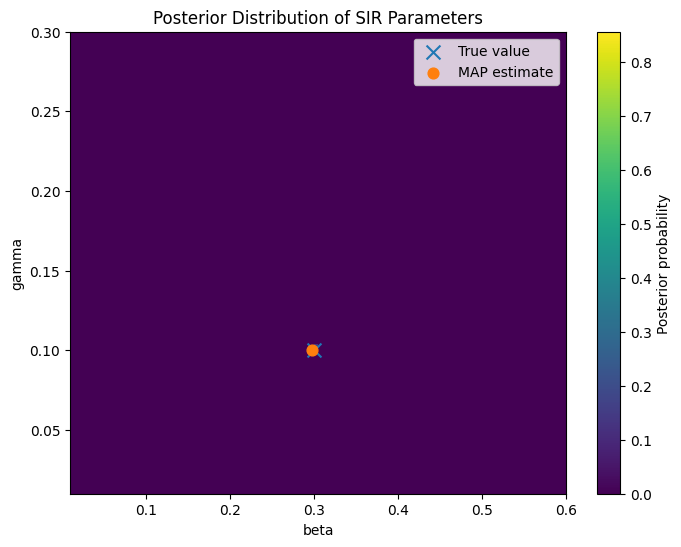

In [8]:
plt.figure(figsize=(8, 6))

extent = [beta_grid.min(), beta_grid.max(), gamma_grid.min(), gamma_grid.max()]

plt.imshow(
    posterior,
    origin="lower",
    aspect="auto",
    extent=extent
)

plt.colorbar(label="Posterior probability")
plt.scatter(beta_true, gamma_true, label="True value", marker="x", s=100)
plt.scatter(beta_map, gamma_map, label="MAP estimate", marker="o", s=60)

plt.xlabel("beta")
plt.ylabel("gamma")
plt.title("Posterior Distribution of SIR Parameters")
plt.legend()
plt.show()

## 8. Simulate fitted trajectories

We compare:
- the true trajectory
- the observed data
- the posterior mean fit
- the MAP fit

In [9]:
S_true, I_true, R_true = solve_sir(beta_true, gamma_true, S0, I0, R0, t)
S_map, I_map, R_map = solve_sir(beta_map, gamma_map, S0, I0, R0, t)
S_mean, I_mean, R_mean = solve_sir(beta_post_mean, gamma_post_mean, S0, I0, R0, t)

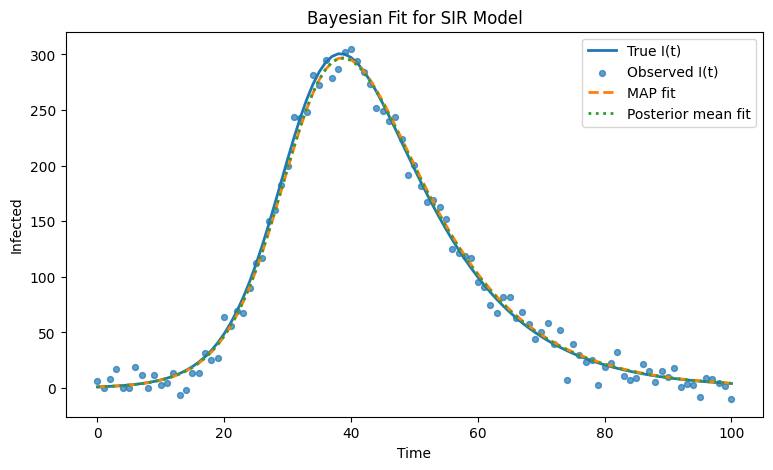

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(t, I_true, label="True I(t)", linewidth=2)
plt.scatter(t, I_obs, label="Observed I(t)", s=18, alpha=0.7)
plt.plot(t, I_map, label="MAP fit", linewidth=2, linestyle="--")
plt.plot(t, I_mean, label="Posterior mean fit", linewidth=2, linestyle=":")

plt.xlabel("Time")
plt.ylabel("Infected")
plt.title("Bayesian Fit for SIR Model")
plt.legend()
plt.show()

## 9. Compare parameter values

In [11]:
comparison_df = pd.DataFrame({
    "parameter": ["beta", "gamma"],
    "true_value": [beta_true, gamma_true],
    "posterior_mean": [beta_post_mean, gamma_post_mean],
    "map_estimate": [beta_map, gamma_map]
})

comparison_df

,parameter,true_value,posterior_mean,map_estimate
0,beta,0.3,0.298273,0.297563
1,gamma,0.1,0.100504,0.100168


## 10. Interpretation

The Bayesian approach provides more than a single point estimate.

It gives the full posterior distribution, which allows us to:
- quantify uncertainty
- visualize parameter dependence
- compare posterior mean and MAP estimates

In this toy example, the posterior should be concentrated near the true values
if the data are informative and the noise level is not too large.

This Bayesian framework naturally extends the likelihood-based approach:

- LS minimizes squared errors
- MLE maximizes likelihood
- Bayesian inference combines likelihood with prior information